In [1]:
import jax
import numpy as np

from crn_jax import models
from crn_jax.plotting import plot_species_trajectories

## Setup

In [2]:
key = jax.random.PRNGKey(0)

In [3]:
def run_and_plot(model, x0, n_steps: int = 1000, params=None, title=None):
    """Simulate one trajectory of ``model`` with initial counts ``x0`` and plot per-species.

    The initial state ``x0`` is a list or array of length ``len(model.SPECIES)``.
    We reshape to ``(1, S)`` for the (n_replicates, n_species) interface of ``sample_trajectories``.
    ``params`` defaults to ``model.Params.default()`` if not supplied — pass a different
    ``Params`` instance (e.g. ``Params.bistable()``) to override the regime.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    x0_arr = np.asarray(x0, dtype=np.float32).reshape(1, len(model.SPECIES))
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0_arr, dt=0.1, n_steps=n_steps)

    if title is None:
        title = model.__name__.rsplit(".", 1)[-1]

    return plot_species_trajectories(dataset, title=title)

## Single-trajectory (N=1) examples

In [ ]:
# Birth-death. A single species is produced at a constant rate and decays first-order;
# the stationary distribution is Poisson with mean α/δ = 50.
# Species: X (the species count).
run_and_plot(models.birth_death, x0=[0], n_steps=5000)  # start empty; relaxes toward ⟨X⟩ ≈ 50

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.01155}


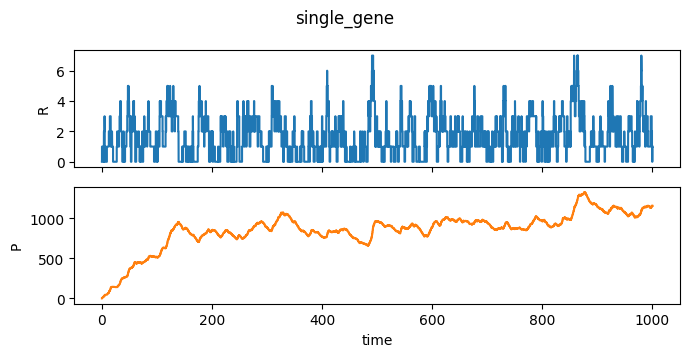

In [ ]:
# Single-gene expression. Transcription produces mRNA constitutively, which is then
# translated into protein; both species decay first-order. The simplest model with a
# hidden delay between input and output.
# Species: R (mRNA), P (protein).

# Start empty: watch how mRNA increases drives protein expression
run_and_plot(models.single_gene, x0=[0, 0], n_steps=10000);

In [ ]:
# Negative autoregulation. A single species represses its own production through a Hill
# term — a classic noise-reducing motif that speeds up response and tightens the
# stationary distribution compared to unregulated expression.
# Species: X (the species count).

# Start above SS so the self-repression visibly pulls X down toward ⟨X⟩ ≈ 18
run_and_plot(models.negative_autoregulation, x0=[80], n_steps=10000)

In [ ]:
# Positive autoregulation. A single species activates its own production through a Hill
# term. With sub-cooperative Hill (n ≤ 1) the equilibrium is monostable and graded; with
# sharper cooperativity and lower leakage the dynamics become switch-like — see the
# next cell for the bistable regime of this same circuit.
# Species: X (the species count).

# Start above SS to see the slow relaxation down to ⟨X⟩ ≈ 46
run_and_plot(models.positive_autoregulation, x0=[100], n_steps=10000)

Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}
Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}


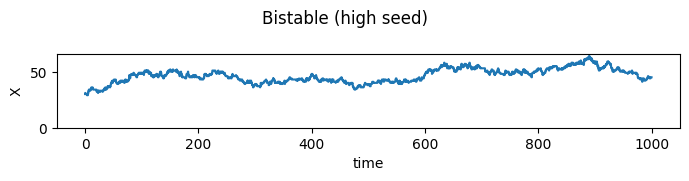

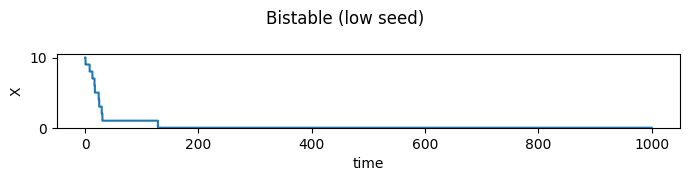

In [7]:
# Bistable self-activation — the same circuit as positive_autoregulation, just in
# the bistable parameter regime.
# Three deterministic fixed points: X=0 (stable, absorbing), X_saddle ≈ 17, X_high ≈ 49.
# Trajectories starting above the saddle commit to the high attractor; below, they
# fall to and stay at zero (β₀ = 0, so X=0 is absorbing).
# Species: X (the species count).

# Seed above the saddle
fig, ax = run_and_plot(
    models.positive_autoregulation,
    x0=[30],
    params=models.positive_autoregulation.Params.bistable(),
    n_steps=10000,
    title="Bistable (high seed)",
)

# Seed below the saddle
fig, ax = run_and_plot(
    models.positive_autoregulation,
    x0=[10],
    params=models.positive_autoregulation.Params.bistable(),
    n_steps=10000,
    title="Bistable (low seed)",
)

In [ ]:
# Linear activation cascade. A is produced at a constant rate and decays first-order.
# A then activates B through a Hill term. The simplest open signalling cascade.
# Species: A (upstream driver), B (downstream target).
# K_A is tuned to ⟨A⟩=50 so the cascade sits at half-activation and B tracks A's variations.
# Steady states: ⟨A⟩ = 50, ⟨B⟩ ≈ 25.5.
run_and_plot(models.linear_cascade, x0=[0, 0], n_steps=5000)  # start empty; A rises first, then drives B

In [ ]:
# Toggle switch (Lugagne et al. 2017 E. coli LacI/TetR fit, adiabatically reduced).
# Two species mutually repress each other; the system is bistable, with LacI-wins
# (A high, B low) and TetR-wins (A low, B high) as stable basins.
# Species: A = LacI, B = TetR. Units: a.u. (fluorescence).
# Three deterministic fixed points: LacI-wins (A≈660, B≈63); TetR-wins (A≈18, B≈864);
# saddle at (A≈73, B≈228). The basins are asymmetric — see docstring.
# n_steps=10000 → ~1000 min ≈ 24× protein decay time, plenty to relax + dwell at SS.
run_and_plot(models.toggle_switch, x0=[0, 300], n_steps=10000)  # seed B above saddle → commits to TetR-wins

In [ ]:
# Incoherent feed-forward loop (Mangan & Alon 2003). A activates both B and C, while B
# represses C. The opposing direct (A→C) and indirect (A→B⊣C) paths produce a pulse /
# adaptive response on C: C transiently rises after A turns on, then falls as the slower
# repression through B kicks in.
# Species: A (input), B (intermediate repressor), C (output).
# Seed A at its SS (50) and B = C = 0 — mimics "input signal just turned on".
# C should peak around ~5–10 then fall toward ~1 as B catches up.
run_and_plot(models.incoherent_ffl, x0=[50, 0, 0], n_steps=5000)

Params: {'beta_A0': 0.03, 'beta_A1': 29.97, 'beta_B0': 0.03, 'beta_B1': 29.97, 'beta_C0': 0.03, 'beta_C1': 29.97, 'K_A': 40.0, 'K_B': 40.0, 'K_C': 40.0, 'n': 2.0, 'delta_A': 0.347, 'delta_B': 0.347, 'delta_C': 0.347}


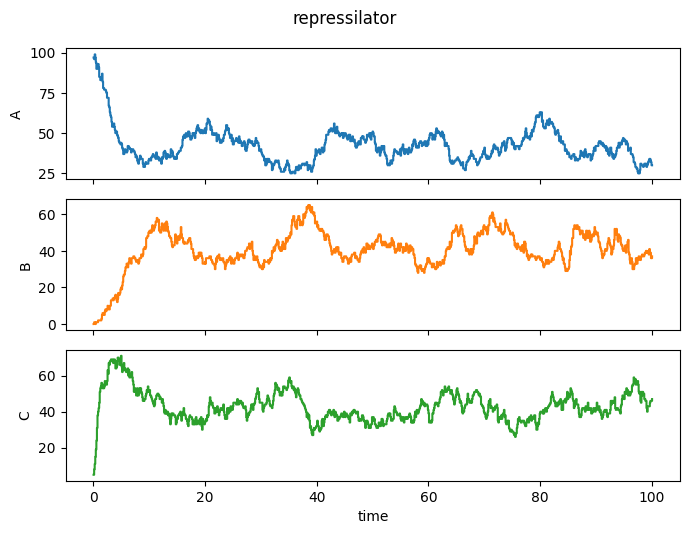

In [16]:
# Repressilator (Elowitz-Leibler, 2000). A three-node repressive ring in which A
# represses B, B represses C, and C represses A. With sufficient Hill cooperativity and a
# clear timescale separation the system enters a stable limit cycle — a synthetic oscillator.
# Species: A, B, C (the three mutually-repressing genes).
run_and_plot(
    models.repressilator, x0=[100, 0, 0]
)  # asymmetric IC breaks the ring's rotational symmetry, seeds the cycle